# Random Forest Regression

## 1. Import Libraries

In [1]:
import pandas as pd # Load and mainpulate tabular data
import numpy as np # Numerical calculations

import matplotlib.pyplot as plt # Visualization

from sklearn.model_selection import train_test_split # Split data into train/test sets
from sklearn.compose import ColumnTransformer # Apply preprocessing by column type
from sklearn.preprocessing import OneHotEncoder # Encode categorical variables
from sklearn.pipeline import Pipeline # Combine preprocessing and model steps

from sklearn.ensemble import RandomForestRegressor # Main Day 13 Model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Regression metrics




# 2. Load Data

In [2]:
df = pd.read_csv("../data/processed/member_analysis_ready.csv") # Load feature-engineered dataset

df.head() # Preview Data

,member_id,age,gender,region,plan_type,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,...,engagement_group,age_group,high_cost_member,chronic_burden_group,sdoh_risk_group,prior_awv_group,total_acute_visits,acute_utilization_group,pcp_status,has_acute_utilization
0,M00001,69,Male,Suburban,Medicare Advantage,40.7,2,68.9,1,1,...,Q4_High,65-79,1,Moderate,Q1_Low,1,2,Low,Attributed,1
1,M00002,32,Female,Urban,DSNP,80.0,3,30.4,0,0,...,Q1_Low,18-34,0,Moderate,Q4_High,0,2,Low,Not Attributed,1
2,M00003,89,Female,Suburban,Medicare Advantage,49.6,3,86.3,1,3,...,Q4_High,80+,0,Moderate,Q2,3,0,NaN,Attributed,0
3,M00004,78,Male,Suburban,Medicare Advantage,45.7,4,63.1,1,1,...,Q4_High,65-79,1,High,Q1_Low,1,3,Moderate,Attributed,1
4,M00005,38,Male,Suburban,Medicare Advantage,32.4,0,55.6,0,0,...,Q4_High,35-49,0,Low,Q1_Low,0,0,NaN,Not Attributed,0


## 3. Define Target and Features

In [3]:
target = "monthly_cost" # Regression target

drop_cols = [
    "member_id",
    "monthly_cost",
    "high_cost_member",
    "awv_completed"
]

X = df.drop(columns = drop_cols) # Feature matrix
y = df[target] # Target vector


## 4. Identify Column Types

In [4]:
categorical_cols = X.select_dtypes(
    include = ["object", "string", "category", "bool"]
).columns.tolist() # Detect categorical columns


numeric_cols = X.select_dtypes(
    include = ["int64", "float64", "int32", "float32"]
).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['gender', 'region', 'plan_type', 'engagement_group', 'age_group', 'chronic_burden_group', 'sdoh_risk_group', 'acute_utilization_group', 'pcp_status']
Numeric columns: ['age', 'sdoh_risk_score', 'chronic_condition_count', 'engagement_score', 'pcp_attributed_24mo', 'prior_awv_count', 'prior_awv_rate', 'ed_visits', 'ip_admits', 'prior_awv_group', 'total_acute_visits', 'has_acute_utilization']


## 5. Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, # Features
    y, # Target
    test_size = 0.20, # Use 20% for testing
    random_state = 42  # Reproducible split
)

## 6. Build Preprocessor

In [6]:
preprocessor = ColumnTransformer(
    transformers = [
        (
            "cat",
            OneHotEncoder(handle_unknown = "ignore"),
            categorical_cols
        )
    ],
    remainder = "passthrough" # Keep numeric variables unchanged
)

## 7. Build Random Forest Model

In [7]:
rf_model = Pipeline(
    steps = [
        ("preprocessor", preprocessor), # Encode categorical variables 
        (
            "model",
            RandomForestRegressor(
                n_estimators = 300, 
                max_depth = None,
                min_samples_leaf = 5,
                random_state = 42,
                n_jobs = -1
            )
        )
    ]
)

## 8. Fit Model

In [8]:
rf_model.fit(X_train, y_train) # Train Random Forest model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

## 9. Evaluate Train and Test Performance

In [9]:
y_train_pred = rf_model.predict(X_train) # Predict training target
y_test_pred = rf_model.predict(X_test) # Predict test target

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

rf_results = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "MAE": [train_mae, test_mae],
    "RMSE": [train_rmse, test_rmse],
    "R2": [train_r2, test_r2]
})

rf_results

,Dataset,MAE,RMSE,R2
0,Train,255.322431,413.097266,0.892409
1,Test,390.499070,665.281386,0.755836


## 10. Actual vs Predicted Plot

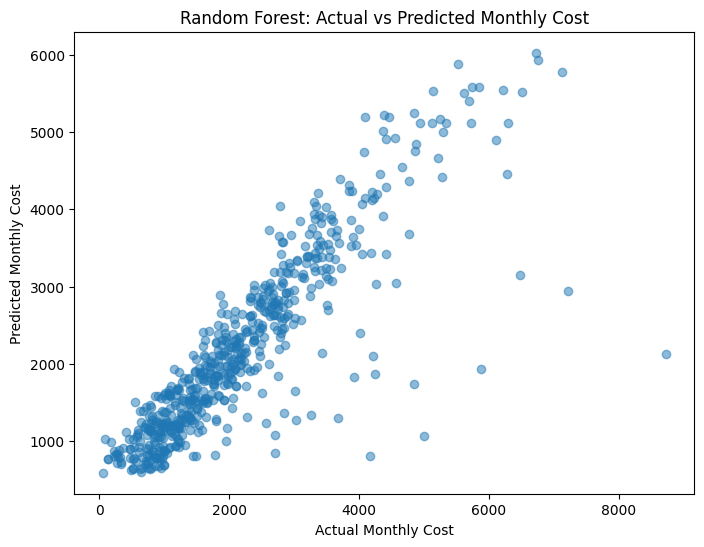

In [10]:
plt.figure(figsize = (8,6))

plt.scatter(y_test, y_test_pred, alpha = 0.5)

plt.xlabel("Actual Monthly Cost")
plt.ylabel("Predicted Monthly Cost")
plt.title("Random Forest: Actual vs Predicted Monthly Cost")

plt.show()

## 11. Residual Plot

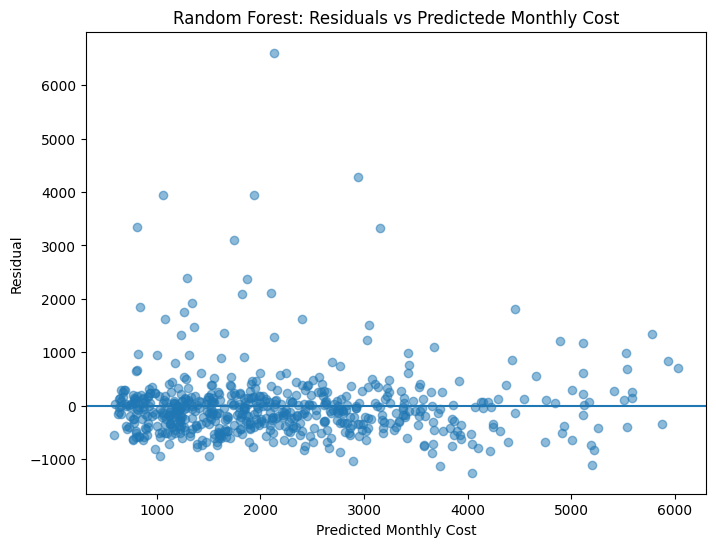

In [11]:
residuals = y_test - y_test_pred # Actual minus predicted

plt.figure(figsize=(8, 6))

plt.scatter(y_test_pred, residuals, alpha = 0.5)
plt.axhline(0, linestyle = "-")

plt.xlabel("Predicted Monthly Cost")
plt.ylabel("Residual")
plt.title("Random Forest: Residuals vs Predictede Monthly Cost")

plt.show() 



## 12. Feature Importance

In [12]:
trained_preprocessor = rf_model.named_steps["preprocessor"] # Access fitted preprocessor
trained_rf = rf_model.named_steps["model"] # Access fitted Random Forest

feature_names = trained_preprocessor.get_feature_names_out() # Get transformed feature names 

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_rf.feature_importances_
}).sort_values(by = "importance", ascending = False)

importance_df.head(20)



,feature,importance
17,cat__chronic_burden_group_High,0.280319
38,remainder__ip_admits,0.264346
32,remainder__chronic_condition_count,0.218904
40,remainder__total_acute_visits,0.067132
33,remainder__engagement_score,0.025625
5,cat__plan_type_DSNP,0.021151
30,remainder__age,0.020394
37,remainder__ed_visits,0.017041
31,remainder__sdoh_risk_score,0.016567
18,cat__chronic_burden_group_Low,0.013250


## 13. Plot Top Feature Importances

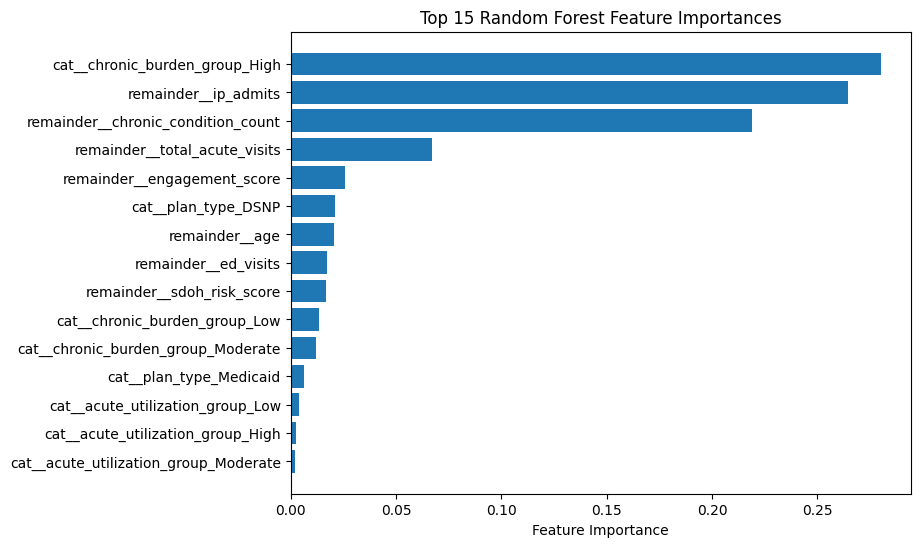

In [13]:
top_features = importance_df.head(15).sort_values(by = "importance")

plt.figure(figsize = (8, 6))

plt.barh(top_features["feature"], top_features["importance"])

plt.xlabel("Feature Importance")
plt.title("Top 15 Random Forest Feature Importances")

plt.show()

## 14. Compare With Day 12 Decision Tree

In [14]:
model_comparison = pd.DataFrame({
    "Model": [
        "Controlled Decision Tree",
        "Random Forest"
    ],
    "Test MAE": [
        463.087564,
        test_mae
    ],
    "Test RMSE": [
        732.191242,
        test_rmse
    ],
    "Test R2": [
    	0.704253,
        test_r2    
    ]
})

## 15. Findings

1. The Random Forest Regressor was used as an ensemble tree-based model for monthly cost prediction.

2. Compared with a single Decision Tree, the Random Forest averages predictions across many trees, which usually reduces overfitting.

3. The model was evaluated using MAE, RMSE, and R² on both training and test data.

4. If the Random Forest has better test RMSE or test R² than the controlled Decision Tree, that suggests the ensemble model generalized better on this synthetic dataset.

5. Feature importance values show which variables were useful for prediction in the fitted forest, but they do not prove causal effects.

6. Because the dataset is synthetic, the results reflect the assumptions built into the data-generation process rather than real-world healthcare evidence.
